In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_FILE = RAW_DATA_DIR / "Customer_Service_Training_Dataset.csv"
VALIDATION_FILE = RAW_DATA_DIR / "Customer_Service_Validation_Dataset.csv"
TEST_FILE = RAW_DATA_DIR / "Customer_Service_Testing_Dataset.csv"

In [2]:
train_df = pd.read_csv(TRAIN_FILE)
validation_df = pd.read_csv(VALIDATION_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Training:", train_df.shape)
print("Validation:", validation_df.shape)
print("Testing:", test_df.shape)

Training: (6539, 4)
Validation: (818, 4)
Testing: (818, 4)


In [3]:
train_df.head(10)

,utterance,intent,category,tags
0,would it be possible to cancel the order I made?,cancel_order,ORDER,BIP
1,cancelling order,cancel_order,ORDER,BK
2,I need assistance canceling the last order I h...,cancel_order,ORDER,B
3,problem with canceling the order I made,cancel_order,ORDER,B
4,I don't know how to cancel the order I made,cancel_order,ORDER,B
5,can you help me cancel the order I made?,cancel_order,ORDER,BI
6,I would like to know about order cancellations,cancel_order,ORDER,BMP
7,could you help me cancelling an order?,cancel_order,ORDER,BIP
8,I don't know how to cancel an order I made,cancel_order,ORDER,B
9,help me cancelling my last order,cancel_order,ORDER,B


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6539 entries, 0 to 6538
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   utterance  6539 non-null   object
 1   intent     6539 non-null   object
 2   category   6539 non-null   object
 3   tags       6539 non-null   object
dtypes: object(4)
memory usage: 204.5+ KB


In [5]:
# Count how many training examples belong to each intent.
# This helps us understand whether the target classes are balanced.
intent_counts = train_df["intent"].value_counts()

# Display the count for each intent.
intent_counts

intent
get_invoice                 268
payment_issue               263
check_invoice               258
contact_customer_service    253
complaint                   252
review                      248
cancel_order                246
check_cancellation_fee      246
check_payment_methods       246
set_up_shipping_address     246
track_order                 245
place_order                 243
check_refund_policy         240
get_refund                  239
registration_problems       239
recover_password            239
track_refund                239
newsletter_subscription     238
create_account              237
delivery_options            236
delete_account              236
delivery_period             236
edit_account                233
change_order                232
switch_account              228
change_shipping_address     228
contact_human_agent         225
Name: count, dtype: int64

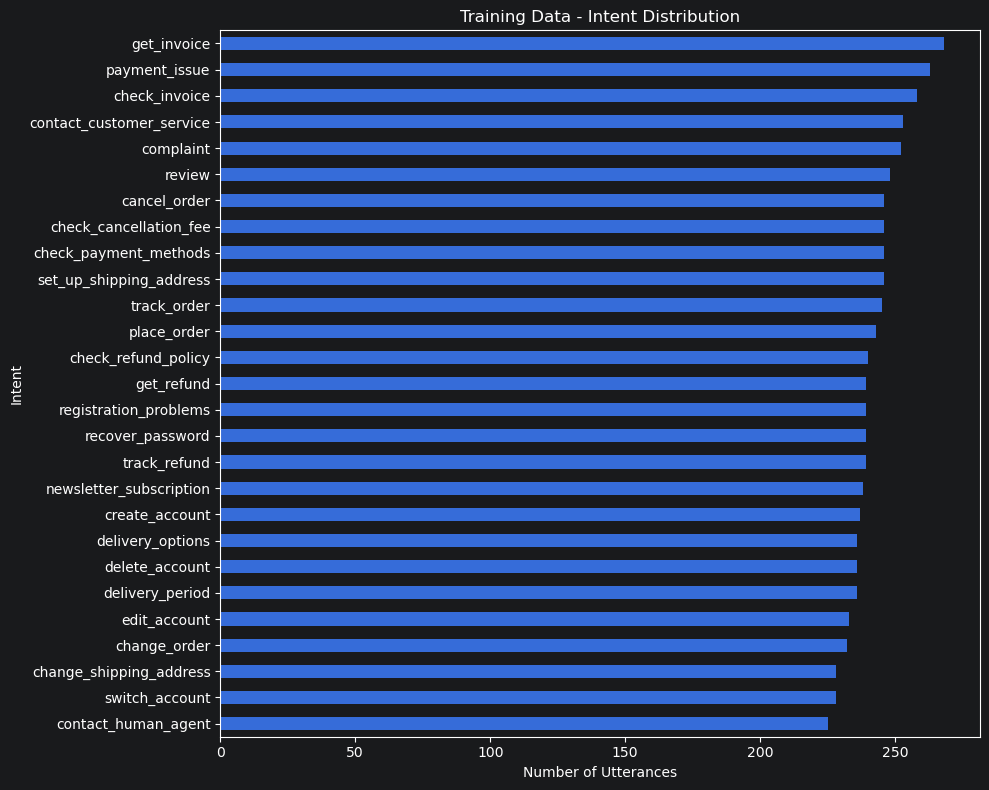

In [6]:
# Plot the number of training examples available for each intent.
# A reasonably even distribution means we are less likely to have
# serious class-imbalance problems during model training.
intent_counts.sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Training Data - Intent Distribution")
plt.xlabel("Number of Utterances")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

In [7]:
# Count the number of training examples belonging to each
# high-level customer service category.
category_counts = train_df["category"].value_counts()

category_counts

category
ACCOUNT             1412
ORDER                966
REFUND               718
INVOICE              526
PAYMENT              509
FEEDBACK             500
CONTACT              478
SHIPPING_ADDRESS     474
DELIVERY             472
CANCELLATION_FEE     246
NEWSLETTER           238
Name: count, dtype: int64

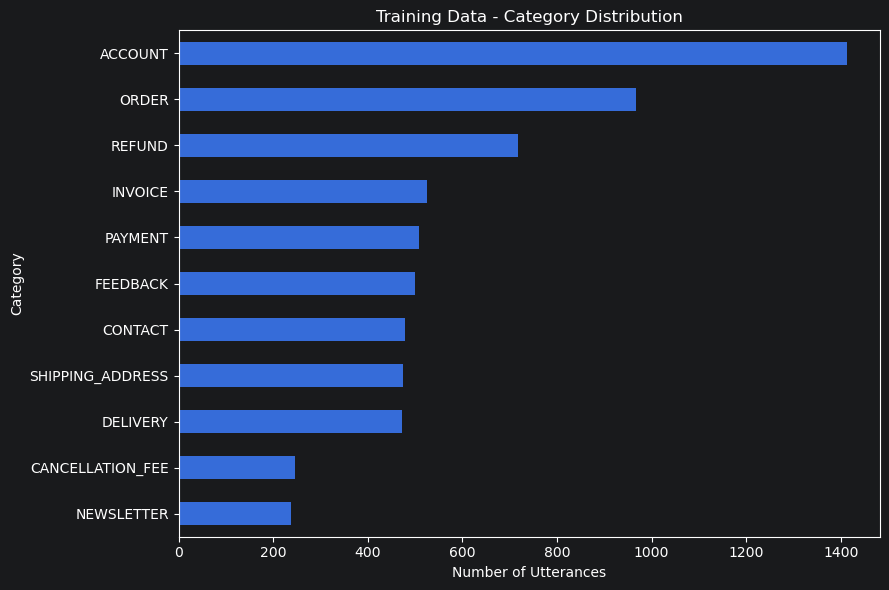

In [8]:
# Visualize the distribution of the 11 high-level categories.
category_counts.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Training Data - Category Distribution")
plt.xlabel("Number of Utterances")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [9]:
# Find the unique category-intent combinations.
# This helps us understand how the broader 'category' column
# relates to our target variable 'intent'.
category_intent_mapping = (
    train_df[["category", "intent"]]
    .drop_duplicates()
    .sort_values(["category", "intent"])
)

category_intent_mapping

,category,intent
2426,ACCOUNT,create_account
2663,ACCOUNT,delete_account
3371,ACCOUNT,edit_account
4855,ACCOUNT,recover_password
5094,ACCOUNT,registration_problems
5827,ACCOUNT,switch_account
706,CANCELLATION_FEE,check_cancellation_fee
1948,CONTACT,contact_customer_service
2201,CONTACT,contact_human_agent
2899,DELIVERY,delivery_options


In [10]:
# Create temporary EDA columns that describe the length of each customer utterance.
# char_length counts characters, while word_count counts whitespace-separated words.
# These help us understand how short or long the customer messages typically are.

train_df["char_length"] = train_df["utterance"].str.len()

train_df["word_count"] = (
    train_df["utterance"]
    .str.split()
    .str.len()
)

# Display summary statistics for both measurements.
train_df[["char_length", "word_count"]].describe()

,char_length,word_count
count,6539.000000,6539.000000
mean,42.554366,8.318244
std,10.618668,2.404325
min,6.000000,1.000000
25%,35.000000,7.000000
50%,43.000000,8.000000
75%,51.000000,10.000000
max,60.000000,15.000000


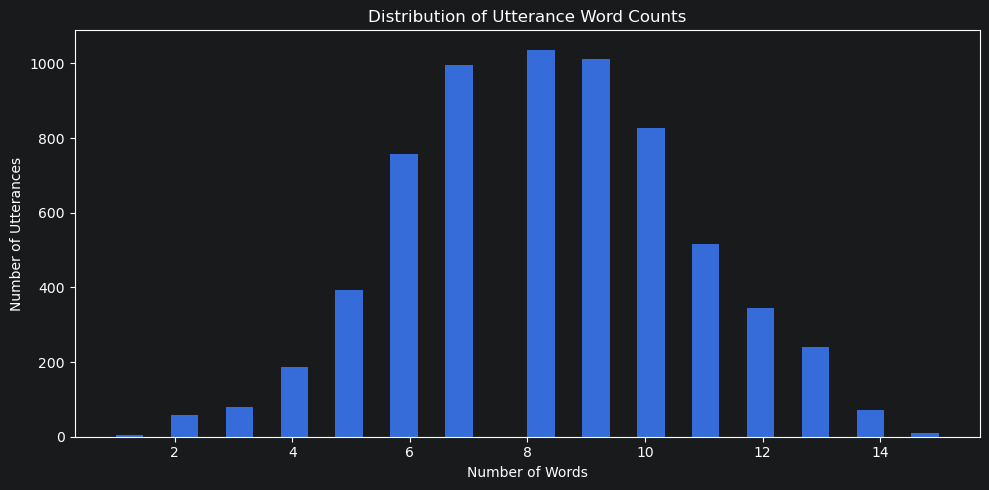

In [11]:
# Plot the distribution of customer-message lengths.
# This helps us see whether most utterances are short or whether
# there are many unusually long customer messages.

train_df["word_count"].plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Distribution of Utterance Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Utterances")
plt.tight_layout()
plt.show()

In [12]:
# Display some of the shortest utterances in the dataset.
# Very short messages can be difficult to classify because they
# may contain little information about the customer's intent.

train_df[
    ["utterance", "intent", "word_count"]
].sort_values("word_count").head(15)

,utterance,intent,word_count
2631,register,create_account,1
2452,registering,create_account,1
5336,review,review,1
1750,complaint,complaint,1
6518,tracking refund,track_refund,2
2029,customer service,contact_customer_service,2
4580,payment issue,payment_issue,2
5846,switch user,switch_account,2
2635,create account,create_account,2
1755,filing complaint,complaint,2


In [13]:
# Display some of the longest utterances.
# This helps us identify unusually verbose examples and will later
# help us choose an appropriate maximum input length for transformers.

train_df[
    ["utterance", "intent", "word_count"]
].sort_values(
    "word_count",
    ascending=False
).head(15)

,utterance,intent,word_count
2601,i do not know what i need to do to open a new ...,create_account,15
4621,I do not know what I need to do to buy some of...,place_order,15
3213,I do not know how I can check how soon can I e...,delivery_period,15
4713,I don't know what I need to do to buy a few of...,place_order,15
5933,i do not know what i have to do to switch to m...,switch_account,15
3977,I do not know what I need to do to get a refun...,get_refund,15
4748,I do not know what I have to do to buy several...,place_order,15
4679,I do not know what I need to do to buy several...,place_order,15
2451,I do not know what I have to do to open a new ...,create_account,15
3948,I do not know what I have to do to get a refun...,get_refund,15


In [14]:
# Check how many utterances contain at least one uppercase character.
# This tells us whether capitalization varies across the dataset.
contains_uppercase = train_df["utterance"].str.contains(
    r"[A-Z]",
    regex=True
).sum()

# Check how many utterances are completely lowercase.
all_lowercase = train_df["utterance"].eq(
    train_df["utterance"].str.lower()
).sum()

print("Total utterances:", len(train_df))
print("Utterances containing uppercase characters:", contains_uppercase)
print("Completely lowercase utterances:", all_lowercase)

Total utterances: 6539
Utterances containing uppercase characters: 3786
Completely lowercase utterances: 2753


In [15]:
# Check how many utterances contain punctuation or other
# non-alphanumeric characters.
#
# We exclude whitespace because spaces are expected in normal sentences.

contains_special_chars = train_df["utterance"].str.contains(
    r"[^\w\s]",
    regex=True
).sum()

print(
    "Utterances containing punctuation/special characters:",
    contains_special_chars
)

Utterances containing punctuation/special characters: 2513


In [16]:
# Display examples containing punctuation/special characters.
# Looking at real examples is important before deciding whether
# punctuation should be removed during preprocessing.

train_df[
    train_df["utterance"].str.contains(r"[^\w\s]", regex=True)
][["utterance", "intent"]].head(20)

,utterance,intent
0,would it be possible to cancel the order I made?,cancel_order
4,I don't know how to cancel the order I made,cancel_order
5,can you help me cancel the order I made?,cancel_order
7,could you help me cancelling an order?,cancel_order
8,I don't know how to cancel an order I made,cancel_order
27,where can I get information about canceling or...,cancel_order
31,can you give me information about cancelling o...,cancel_order
33,I don't know how to cancel my last order,cancel_order
37,how can I find information about cancelling or...,cancel_order
41,can you help me to cancel the last order I hav...,cancel_order


In [17]:
# Check whether customer utterances contain numbers.
# Numbers can sometimes carry useful information in real support tickets,
# such as order numbers, amounts, dates or quantities.

contains_numbers = train_df["utterance"].str.contains(
    r"\d",
    regex=True
).sum()

print("Utterances containing numbers:", contains_numbers)

Utterances containing numbers: 66
